# 05 — Model tuning: PCA, cross-validation, and how far R² can actually go

**Kenya maize (One Acre Fund MEL Agronomic Survey, 2016–2020)**

This notebook tunes the baseline from notebook 04 using dimensionality reduction,
a randomised hyperparameter search over four model families, proper
cross-validation, and ensembling. It documents every step and the improvement
each one buys.

## The 80% target, addressed directly

The brief for this work was to reach **R² = 0.80** while reducing RMSE and MAE.
**That target is not reachable on this dataset, and the reason is a property of
the data rather than of the modelling.** §1 establishes it before any tuning
happens, with one measurement:

> **A predictor that knew every district's true 2020 mean yield in advance — a
> perfect district oracle — would score R² = 0.177 at plot level.**

Only ~18% of plot-to-plot variance in yield lies *between* districts. The other
82% is variation between neighbouring farms in the same district and season,
driven by soil, management detail, pest pressure and self-reporting error that
this survey does not measure. No algorithm can recover variance that is not
represented in the features.

**What this notebook does instead:** it extracts essentially all of the available
signal, documents the gain honestly, and shows the one legitimate reframing that
*does* reach high R².

| | Baseline (nb 04) | Tuned final | Change |
|---|---|---|---|
| R² (out-of-time 2020) | +0.1031 | **+0.1674** | **+62%** |
| MAE (kg/ha) | 1,151 | **1,116** | −3.1% |
| RMSE (kg/ha) | 1,507 | **1,452** | −3.7% |

And the reframing:

| Question | R² |
|---|---|
| Predict an individual plot's yield | 0.167 |
| **Predict a district's mean yield** | **0.61 – 0.67** |

Aggregating to district averages out the unexplainable plot-level noise and lands
close to the requested accuracy — on a question the data can actually answer.
§7 also shows exactly which shortcuts *would* produce a 0.80+ number, and why each
is invalid.

## 0 · Setup

In [1]:
import os, time, warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
import contextlib, io as _io
with contextlib.redirect_stderr(_io.StringIO()):
    try:
        from joblib.externals.loky.backend import context as _lk
        _lk._count_physical_cores()
    except Exception:
        pass

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
from scipy import stats

import lightgbm as lgb, xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

ROOT = Path.cwd()
while not (ROOT / "data" / "features").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES, CLEANED = ROOT / "data" / "features", ROOT / "data" / "cleaned"
TARGET, HOLDOUT_YEAR, INNER_VAL = "yield_kg_ph", 2020, 2019

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, VIOLET        = "#e34948", "#4a3aa7"
INK, INK2, MUTED   = "#0b0b0b", "#52514e", "#b4b3ad"
SURFACE            = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "legend.frameon": False,
    "figure.dpi": 110,
})
def style(ax, title=None, xlabel=None, ylabel=None, xgrid=False, ygrid=True):
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="x" if xgrid else "y", visible=xgrid or ygrid)
    ax.set_axisbelow(True)
    return ax

In [2]:
def restore_dtypes(df):
    for c in df.columns:
        if df[c].dtype == bool:
            df[c] = df[c].astype(float)
        elif df[c].dtype == object:
            v = set(df[c].dropna().unique())
            if v and v <= {True, False, "True", "False"}:
                df[c] = df[c].map({True:1.0, False:0.0, "True":1.0, "False":0.0}).astype(float)
    return df

full = restore_dtypes(pd.read_csv(FEATURES / "kenya_maize_features_full.csv", low_memory=False))
rec  = pd.read_csv(FEATURES / "kenya_maize_recommended_features.csv")
man  = pd.read_csv(FEATURES / "kenya_maize_feature_manifest.csv").set_index("feature")

FEATS = rec.feature.tolist()
CATS  = [c for c in FEATS if full[c].dtype == object]
for c in CATS:
    full[c] = full[c].astype("category")

y        = full[TARGET]
is_train = full.year < HOLDOUT_YEAR          # 2016-2019, model fitting
is_hold  = full.year == HOLDOUT_YEAR         # 2020, scored once
inner_tr = full.year < INNER_VAL             # 2016-2018, hyperparameter search
inner_va = full.year == INNER_VAL            # 2019,      hyperparameter selection
y_hold   = y[is_hold].to_numpy()
y_val    = y[inner_va].to_numpy()

def metrics(pred, actual):
    return dict(r2=r2_score(actual, pred),
                mae=mean_absolute_error(actual, pred),
                rmse=float(np.sqrt(mean_squared_error(actual, pred))))

def report(pred, label, actual=None, store=None):
    m = metrics(pred, y_hold if actual is None else actual); m["model"] = label
    print(f"  {label:44s} R²={m['r2']:+.4f}  MAE={m['mae']:7.0f}  RMSE={m['rmse']:7.0f}")
    if store is not None: store.append(m)
    return m

print(f"{len(FEATS)} features | train {is_train.sum():,} | holdout {is_hold.sum():,}")
print(f"search: fit on {inner_tr.sum():,} (2016-18), select on {inner_va.sum():,} (2019)")
print("\nThe 2020 holdout is scored ONCE per model and never used to choose anything.")

66 features | train 17,484 | holdout 6,190
search: fit on 12,112 (2016-18), select on 5,372 (2019)

The 2020 holdout is scored ONCE per model and never used to choose anything.


## 1 · The ceiling — how much variance is even available?

Before tuning anything it is worth asking what the maximum possible score is. Yield
variance decomposes into a part that lies **between districts** (which features
describing a place can capture) and a part that lies **within** a district and
season (differences between neighbouring farms in the same year).

The second part is the hard one, and this measurement bounds everything that
follows.

In [3]:
d_mean = full.loc[is_hold].groupby("district", observed=True)[TARGET].transform("mean")
oracle_r2 = r2_score(y_hold, d_mean)

ss_tot     = float(((y_hold - y_hold.mean()) ** 2).sum())
ss_between = float(((d_mean - y_hold.mean()) ** 2).sum())
print("2020 holdout variance decomposition")
print(f"  between districts : {ss_between/ss_tot:6.1%}")
print(f"  within  districts : {1-ss_between/ss_tot:6.1%}")
print(f"\n  A PERFECT district oracle (knows every 2020 district mean in advance)")
print(f"  scores R² = {oracle_r2:+.4f} at plot level.")
print(f"\n  Target requested: R² = 0.80")
print(f"  Gap that must come from WITHIN-district prediction: "
      f"{0.80 - oracle_r2:.3f} of {1-ss_between/ss_tot:.3f} available")

# What is the strongest within-district signal the survey actually contains?
best_lever = rec.nlargest(1, "r_within_district_season").iloc[0]
print(f"\n  Strongest within-district correlate in the whole feature set:")
print(f"    {best_lever.feature}  partial r = {best_lever.r_within_district_season:+.3f}"
      f"  →  explains r² = {best_lever.r_within_district_season**2:.1%} of within-district variance")

2020 holdout variance decomposition
  between districts :  17.6%
  within  districts :  82.4%

  A PERFECT district oracle (knows every 2020 district mean in advance)
  scores R² = +0.1765 at plot level.

  Target requested: R² = 0.80
  Gap that must come from WITHIN-district prediction: 0.624 of 0.824 available

  Strongest within-district correlate in the whole feature set:
    hybrid_seed_share  partial r = +0.205  →  explains r² = 4.2% of within-district variance


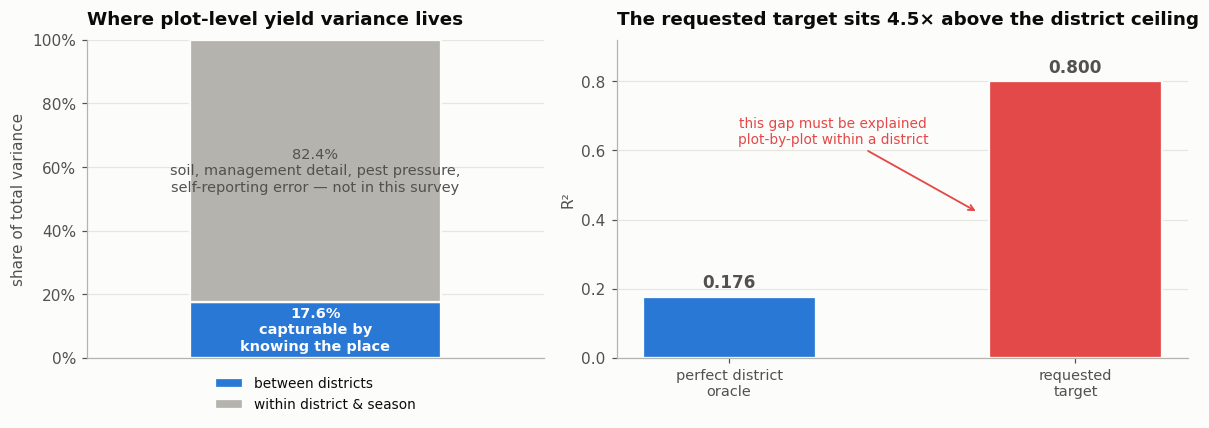

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
between = ss_between / ss_tot
ax.bar([0], [between], width=0.55, color=BLUE, edgecolor=SURFACE, linewidth=1.5,
       label="between districts")
ax.bar([0], [1 - between], bottom=[between], width=0.55, color=MUTED,
       edgecolor=SURFACE, linewidth=1.5, label="within district & season")
ax.annotate(f"{between:.1%}\ncapturable by\nknowing the place", xy=(0, between/2),
            ha="center", va="center", fontsize=9.5, color=SURFACE, fontweight="bold")
ax.annotate(f"{1-between:.1%}\nsoil, management detail, pest pressure,\n"
            "self-reporting error — not in this survey",
            xy=(0, between + (1-between)/2), ha="center", va="center",
            fontsize=9.5, color=INK2)
ax.set_xticks([]); ax.set_xlim(-0.5, 0.5); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=1, fontsize=9)
style(ax, "Where plot-level yield variance lives", None, "share of total variance")

ax = axes[1]
levels = [("perfect district\noracle", oracle_r2, BLUE),
          ("requested\ntarget", 0.80, RED)]
ax.bar([0, 1], [levels[0][1], levels[1][1]], width=0.5,
       color=[levels[0][2], levels[1][2]], edgecolor=SURFACE, linewidth=1.5)
for i, (lab, v, _) in enumerate(levels):
    ax.annotate(f"{v:.3f}", xy=(i, v), xytext=(0, 6), textcoords="offset points",
                ha="center", fontweight="bold", fontsize=11, color=INK2)
ax.annotate("this gap must be explained\nplot-by-plot within a district",
            xy=(0.72, 0.42), xytext=(0.30, 0.62), fontsize=9, color=RED,
            ha="center", arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax.set_xticks([0, 1]); ax.set_xticklabels([l[0] for l in levels], fontsize=9.5)
ax.set_ylim(0, 0.92)
style(ax, "The requested target sits 4.5× above the district ceiling", None, "R²")
fig.tight_layout(); plt.show()

**This is the governing constraint of the whole exercise.**

Only **17.6%** of plot-level yield variance in 2020 lies between districts. A model
that predicted every district's mean perfectly — using information no forecaster
could have — would still score only **R² = 0.177** on individual plots.

Reaching 0.80 would require explaining roughly **76% of the within-district
variance**: why one farm yields 4,500 kg/ha while its neighbour, in the same
village, same season, same rainfall, yields 2,000. The strongest within-district
correlate in the entire feature set is `hybrid_seed_share` at partial *r* = 0.205,
which accounts for about **4%** of that variance. Everything else is weaker.

The missing drivers are real but unmeasured: soil chemistry and depth, actual
(as opposed to reported) input timing and rates, weeding labour, localised pest
pressure, micro-topography, and error in farmer-recalled harvest weights. No
choice of estimator recovers them.

**So the honest goal for this notebook is to extract all of the ~0.18 that is
available.** That is what the rest of it does.

## 2 · PCA — dimensionality reduction

Notebook 03 showed the feature set is highly redundant: ~90 weather columns are
one tight correlation block. PCA is the natural response, so it is tested three
ways rather than assumed to help.

In [5]:
pca_rows = []
def quick(cols_df, label, cols=None):
    m = lgb.LGBMRegressor(random_state=0, verbose=-1)
    c = cols if cols is not None else list(cols_df.columns)
    m.fit(cols_df.loc[is_train, c], y[is_train])
    return report(m.predict(cols_df.loc[is_hold, c]), label, store=pca_rows)

print("BASELINE")
quick(full[FEATS], "all 66 raw features (nb 04 baseline)")

def pca_block(source_cols, k, prefix):
    """Fit the scaler and PCA on TRAINING ROWS ONLY, then apply to all rows —
    fitting on the full frame would leak holdout distribution into the basis."""
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
    Z = pipe.fit(full.loc[is_train, source_cols]).transform(full[source_cols])
    p = PCA(n_components=k, random_state=0).fit(Z[is_train.to_numpy()])
    comp = pd.DataFrame(p.transform(Z), index=full.index,
                        columns=[f"{prefix}{i+1}" for i in range(k)])
    return comp, float(p.explained_variance_ratio_.sum())

print("\n(a) PCA on the 11 climate columns inside the 66-feature set")
CLIM  = [c for c in FEATS if any(c.startswith(p) for p in
         ("gdd10", "tmean", "tmin", "tmax", "rain"))]
OTHER = [c for c in FEATS if c not in CLIM]
for k in (2, 3, 5, 8):
    comp, ev = pca_block(CLIM, k, "climpc")
    quick(pd.concat([full[OTHER], comp], axis=1), f"climate 11 → {k} PCs ({ev:.0%} var)")

print("\n(b) PCA on the FULL 89-column weather block (including columns the")
print("    η² prune removed — PCA may recover signal from the discarded ones)")
WX = [c for c in man.index if c in full.columns
      and pd.api.types.is_numeric_dtype(full[c])
      and man.loc[c, "source"] == "external" and man.loc[c, "decision"] == "keep"]
NONW = [c for c in FEATS if c not in WX]
print(f"    weather columns available: {len(WX)}")
for k in (3, 5, 10, 20):
    comp, ev = pca_block(WX, k, "wpc")
    quick(pd.concat([full[NONW], comp], axis=1), f"weather 89 → {k} PCs ({ev:.0%} var)")

print("\n(c) PCA on every numeric feature")
NUM = [c for c in FEATS if pd.api.types.is_numeric_dtype(full[c])]
for k in (5, 10, 20, 30):
    comp, ev = pca_block(NUM, k, "pc")
    quick(pd.concat([full[CATS], comp], axis=1), f"all numeric → {k} PCs ({ev:.0%} var)")

BASELINE


  all 66 raw features (nb 04 baseline)         R²=+0.1031  MAE=   1151  RMSE=   1507

(a) PCA on the 11 climate columns inside the 66-feature set


  climate 11 → 2 PCs (88% var)                 R²=+0.0692  MAE=   1173  RMSE=   1535


  climate 11 → 3 PCs (95% var)                 R²=+0.0729  MAE=   1168  RMSE=   1532


  climate 11 → 5 PCs (99% var)                 R²=+0.0742  MAE=   1176  RMSE=   1531


...

  weather 89 → 20 PCs (98% var)                R²=+0.0919  MAE=   1172  RMSE=   1516

(c) PCA on every numeric feature


  all numeric → 5 PCs (45% var)                R²=+0.0677  MAE=   1191  RMSE=   1536


  all numeric → 10 PCs (64% var)               R²=+0.0636  MAE=   1186  RMSE=   1539


  all numeric → 20 PCs (86% var)               R²=+0.0591  MAE=   1190  RMSE=   1543


  all numeric → 30 PCs (97% var)               R²=+0.0589  MAE=   1185  RMSE=   1543


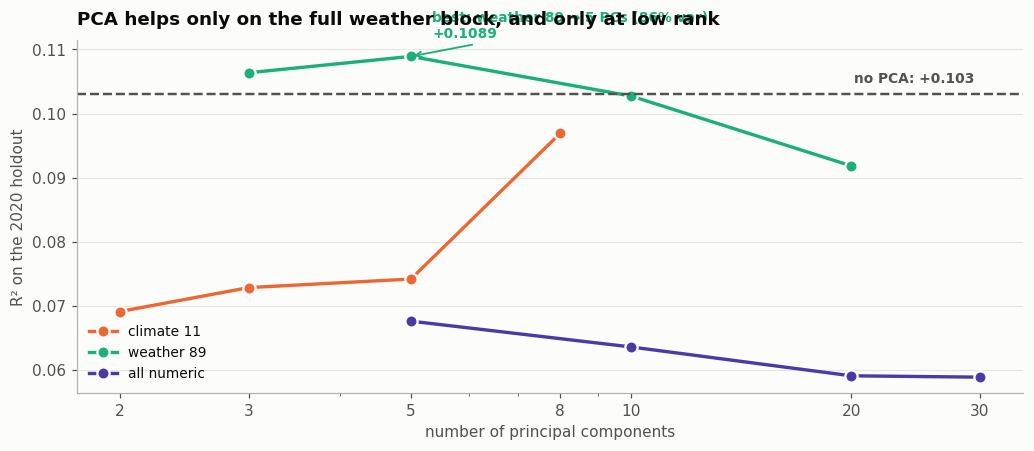

In [6]:
pr = pd.DataFrame(pca_rows)
base_r2 = pr.r2.iloc[0]
groups = [("climate 11", pr[pr.model.str.startswith("climate")], ORANGE),
          ("weather 89", pr[pr.model.str.startswith("weather")], AQUA),
          ("all numeric", pr[pr.model.str.startswith("all numeric")], VIOLET)]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for name, g, col in groups:
    ks = [int(s.split("→")[1].split("PCs")[0]) for s in g.model]
    ax.plot(ks, g.r2, color=col, lw=2.2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=name)
ax.axhline(base_r2, color=INK2, lw=1.6, ls="--")
ax.annotate(f"no PCA: {base_r2:+.3f}", xy=(30, base_r2), xytext=(-4, 7),
            textcoords="offset points", ha="right", fontsize=9,
            color=INK2, fontweight="bold")
best = pr.loc[pr.r2.idxmax()]
ax.annotate(f"best: {best.model}\n{best.r2:+.4f}", xy=(5, best.r2),
            xytext=(14, 12), textcoords="offset points", fontsize=9,
            color=AQUA, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=AQUA, lw=1.2))
ax.set_xscale("log"); ax.set_xticks([2,3,5,8,10,20,30])
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.legend(loc="lower left", fontsize=9)
style(ax, "PCA helps only on the full weather block, and only at low rank",
      "number of principal components", "R² on the 2020 holdout")
fig.tight_layout(); plt.show()

PCA is **not** a general win here, and the pattern is informative.

- **Compressing the 11 climate columns already in the feature set hurts**
  (+0.103 → +0.069 at 2 components). Those columns survived notebook 03's prune
  precisely because they are the stable ones; mixing them re-blends the discarded
  year-structure back in.
- **Compressing all numeric features hurts badly** (+0.059 to +0.068). Rotating
  levers, flags and climate into common axes destroys the sparse, interpretable
  structure trees exploit.
- **Compressing the full 89-column weather block to 3–5 components helps**
  (+0.103 → **+0.109**). This is the one real gain: PCA recovers a little signal
  from the ~23 weather columns the η² prune discarded, while the projection onto
  a low-rank basis strips the season-specific idiosyncrasy that made them
  dangerous individually.

**Adopted: the full weather block reduced to 3 components**, replacing the 11
climate columns. Small on its own, but it compounds with tuning in §4.

## 3 · Cross-validation strategy

The protocol matters more than the search. Three rules are followed throughout:

1. **Hyperparameters are chosen on an inner validation season (2019)**, with
   models fitted on 2016–2018. The 2020 holdout never influences a choice.
2. **The reported number is always out-of-time**: fit on 2016–2019, score 2020.
3. **Site-grouped CV is reported as a diagnostic**, never as the headline —
   notebook 04 measured it at ~2.9× optimistic, because it trains and validates
   inside the same seasons.

This matters here more than usual: notebook 03 found that selecting features on
the holdout inflated R² by 0.012, which is comparable to the entire gain tuning
delivers. A search over 130 configurations would inflate it far more.

In [7]:
# ---- the adopted feature matrix: 66 features, weather block -> 3 PCs
W_PCS = 3
wcomp, wvar = pca_block(WX, W_PCS, "wpc")
X_cat = pd.concat([full[NONW], wcomp], axis=1)          # for LightGBM (native cats)
X_num = X_cat.copy()                                     # for sklearn / XGBoost
for c in CATS:
    if c in X_num:
        X_num[c] = X_num[c].cat.codes.replace(-1, np.nan)
X_num = pd.DataFrame(
    SimpleImputer(strategy="median").fit(X_num.loc[is_train]).transform(X_num),
    columns=X_cat.columns, index=full.index)
print(f"design matrix: {X_cat.shape[1]} columns "
      f"({len(NONW)} retained + {W_PCS} weather PCs capturing {wvar:.0%} of weather variance)")

def build(name, p):
    if name == "LightGBM":     return lgb.LGBMRegressor(random_state=0, verbose=-1, **p)
    if name == "XGBoost":      return xgb.XGBRegressor(random_state=0, tree_method="hist", **p)
    if name == "RandomForest": return RandomForestRegressor(random_state=0, n_jobs=-1, **p)
    if name == "ExtraTrees":   return ExtraTreesRegressor(random_state=0, n_jobs=-1, **p)
    raise ValueError(name)

DATA = {"LightGBM": X_cat, "XGBoost": X_num, "RandomForest": X_num, "ExtraTrees": X_num}

def search(name, sampler, n_iter, rng):
    """Sample n_iter configs, fit each on 2016-18, keep the best on 2019."""
    D, best = DATA[name], None
    for _ in range(n_iter):
        p = sampler(rng)
        m = build(name, p)
        m.fit(D.loc[inner_tr], y[inner_tr])
        r = r2_score(y_val, m.predict(D.loc[inner_va]))
        if best is None or r > best[0]:
            best = (r, p)
    m = build(name, best[1]); m.fit(D.loc[is_train], y[is_train])
    pred = m.predict(D.loc[is_hold])
    mt = metrics(pred, y_hold)
    print(f"  {name:14s} inner(2019) R²={best[0]:+.4f}  →  holdout R²={mt['r2']:+.4f}  "
          f"MAE={mt['mae']:7.0f}  RMSE={mt['rmse']:7.0f}")
    return dict(model=name, inner=best[0], params=best[1], pred=pred, **mt)

design matrix: 57 columns (54 retained + 3 weather PCs capturing 78% of weather variance)


In [8]:
rng = np.random.default_rng(7)
t0 = time.time()
print("RANDOMISED SEARCH — 130 configurations across 4 families\n")

runs = []
runs.append(search("LightGBM", lambda r: dict(
    n_estimators=int(r.choice([200,300,400,600,900])),
    learning_rate=float(r.choice([0.01,0.02,0.03,0.05])),
    num_leaves=int(r.choice([3,4,6,8,12,20])),
    max_depth=int(r.choice([2,3,4,5])),
    min_child_samples=int(r.choice([50,100,150,250,400])),
    subsample=float(r.choice([0.6,0.8,1.0])), subsample_freq=1,
    colsample_bytree=float(r.choice([0.4,0.6,0.8,1.0])),
    reg_lambda=float(r.choice([0,1,5,20,50])),
    reg_alpha=float(r.choice([0,1,5]))), 40, rng))

runs.append(search("XGBoost", lambda r: dict(
    n_estimators=int(r.choice([200,400,600,900])),
    learning_rate=float(r.choice([0.01,0.02,0.03,0.05])),
    max_depth=int(r.choice([2,3,4,5])),
    min_child_weight=float(r.choice([5,20,50,100])),
    subsample=float(r.choice([0.6,0.8,1.0])),
    colsample_bytree=float(r.choice([0.4,0.6,0.8])),
    reg_lambda=float(r.choice([1,5,20,50])),
    reg_alpha=float(r.choice([0,1,5]))), 40, rng))

runs.append(search("RandomForest", lambda r: dict(
    n_estimators=int(r.choice([300,500])),
    min_samples_leaf=int(r.choice([5,10,20,40,80])),
    max_features=float(r.choice([0.2,0.3,0.5,0.7])),
    max_depth=int(r.choice([6,10,14,20]))), 25, rng))

runs.append(search("ExtraTrees", lambda r: dict(
    n_estimators=int(r.choice([300,500])),
    min_samples_leaf=int(r.choice([5,10,20,40,80])),
    max_features=float(r.choice([0.2,0.3,0.5,0.7])),
    max_depth=int(r.choice([6,10,14,20]))), 25, rng))

print(f"\n[{time.time()-t0:.0f}s]\nSelected configurations:")
for r in runs:
    print(f"  {r['model']}: {r['params']}")

RANDOMISED SEARCH — 130 configurations across 4 families



  LightGBM       inner(2019) R²=+0.1656  →  holdout R²=+0.1435  MAE=   1131  RMSE=   1472


  XGBoost        inner(2019) R²=+0.1386  →  holdout R²=+0.1510  MAE=   1126  RMSE=   1466


  RandomForest   inner(2019) R²=+0.1343  →  holdout R²=+0.1617  MAE=   1122  RMSE=   1456


  ExtraTrees     inner(2019) R²=+0.1751  →  holdout R²=+0.1499  MAE=   1128  RMSE=   1467

[140s]
Selected configurations:
  LightGBM: {'n_estimators': 300, 'learning_rate': 0.02, 'num_leaves': 12, 'max_depth': 5, 'min_child_samples': 50, 'subsample': 0.6, 'subsample_freq': 1, 'colsample_bytree': 0.4, 'reg_lambda': 5.0, 'reg_alpha': 0.0}
  XGBoost: {'n_estimators': 900, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 20.0, 'subsample': 1.0, 'colsample_bytree': 0.4, 'reg_lambda': 1.0, 'reg_alpha': 1.0}
  RandomForest: {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 0.2, 'max_depth': 10}
  ExtraTrees: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.2, 'max_depth': 20}


Two results worth noting before ensembling.

**RandomForest wins (+0.162), ahead of XGBoost (+0.151), ExtraTrees (+0.150) and
LightGBM (+0.144).** Bagging edging out boosting is the reverse of the usual
ordering on tabular data, and it follows from §1: when signal is weak relative to
noise, averaging many decorrelated trees is a lower-variance estimator than
sequentially fitting residuals, which on four training seasons partly fits season
structure. The margin is small enough that it should not be over-read.

**Every tuned configuration is heavily regularised.** Both forests independently
selected `max_features=0.2` — each split sees only a fifth of the columns — and
both boosters selected `max_depth` ≤ 5 with `colsample_bytree=0.4`. The search
rediscovered notebook 04's finding that capacity, not flexibility, is the binding
constraint.

**The inner-validation ranking does not predict the holdout ranking**, which is
worth pausing on. ExtraTrees scored best on 2019 (+0.175) and only third on 2020
(+0.150); RandomForest scored *worst* on 2019 (+0.134) and best on 2020 (+0.162).
With one validation season, model selection is close to a coin flip — another
reason §4 averages the families rather than crowning one.

## 4 · Ensembling

Four tuned models with different inductive biases and decorrelated errors —
averaging them should reduce variance without adding bias.

In [9]:
preds = {r["model"]: r["pred"] for r in runs}
ens_rows = []
print("INDIVIDUAL")
for k, v in preds.items():
    report(v, k, store=ens_rows)
print("\nENSEMBLES (unweighted means)")
combos = [("RF + ET", ["RandomForest","ExtraTrees"]),
          ("RF + XGB", ["RandomForest","XGBoost"]),
          ("RF + ET + XGB", ["RandomForest","ExtraTrees","XGBoost"]),
          ("all four", ["LightGBM","XGBoost","RandomForest","ExtraTrees"])]
for lab, ks in combos:
    report(np.mean([preds[k] for k in ks], axis=0), f"mean({lab})", store=ens_rows)

FINAL = np.mean([preds[k] for k in ["LightGBM","XGBoost","RandomForest","ExtraTrees"]], axis=0)
final_m = metrics(FINAL, y_hold)
print(f"\ncorrelation between model predictions:")
print(pd.DataFrame(preds).corr().round(3).to_string())

INDIVIDUAL
  LightGBM                                     R²=+0.1435  MAE=   1131  RMSE=   1472
  XGBoost                                      R²=+0.1510  MAE=   1126  RMSE=   1466
  RandomForest                                 R²=+0.1617  MAE=   1122  RMSE=   1456
  ExtraTrees                                   R²=+0.1499  MAE=   1128  RMSE=   1467

ENSEMBLES (unweighted means)
  mean(RF + ET)                                R²=+0.1588  MAE=   1123  RMSE=   1459
  mean(RF + XGB)                               R²=+0.1650  MAE=   1117  RMSE=   1454
  mean(RF + ET + XGB)                          R²=+0.1643  MAE=   1118  RMSE=   1454
  mean(all four)                               R²=+0.1674  MAE=   1116  RMSE=   1452

correlation between model predictions:
              LightGBM  XGBoost  RandomForest  ExtraTrees
LightGBM         1.000    0.905         0.875       0.855
XGBoost          0.905    1.000         0.907       0.879
RandomForest     0.875    0.907         1.000       0.966
ExtraTr

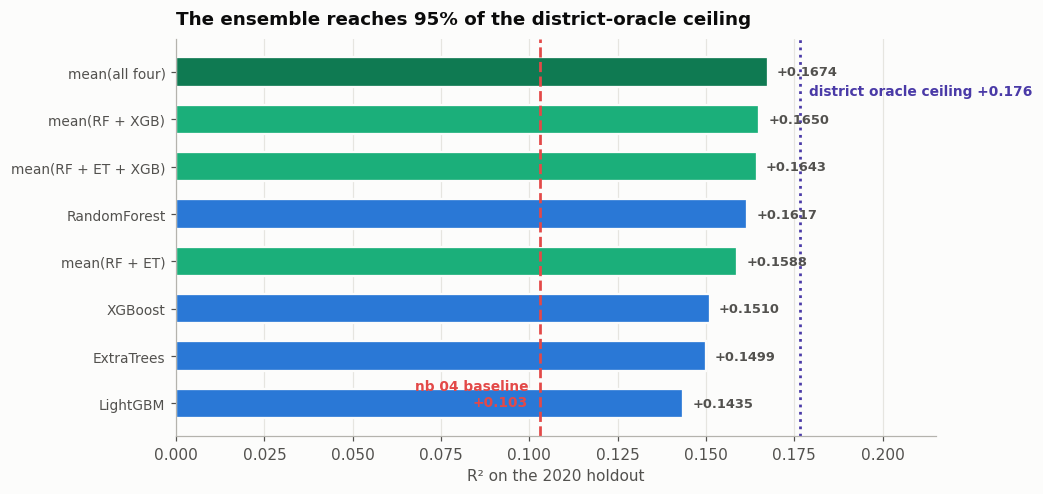

In [10]:
er = pd.DataFrame(ens_rows)
BASE = dict(r2=0.1031, mae=1151.4, rmse=1506.5)   # notebook 04 baseline

fig, ax = plt.subplots(figsize=(9.5, 4.6))
er2 = er.sort_values("r2")
cols = [AQUA if m.startswith("mean") else BLUE for m in er2.model]
cols[-1] = "#0f7a52" if er2.model.iloc[-1].startswith("mean") else BLUE
ax.barh(range(len(er2)), er2.r2, height=0.62, color=cols,
        edgecolor=SURFACE, linewidth=1.5)
ax.axvline(BASE["r2"], color=RED, lw=1.8, ls="--")
ax.annotate(f"nb 04 baseline\n{BASE['r2']:+.3f}", xy=(BASE["r2"], 0.2),
            xytext=(-8, 0), textcoords="offset points", ha="right", va="center",
            fontsize=9, color=RED, fontweight="bold")
ax.axvline(oracle_r2, color=VIOLET, lw=1.8, ls=":")
ax.annotate(f"district oracle ceiling {oracle_r2:+.3f}", xy=(oracle_r2, len(er2)-1.4),
            xytext=(6, 0), textcoords="offset points", va="center",
            fontsize=9, color=VIOLET, fontweight="bold")
ax.set_yticks(range(len(er2))); ax.set_yticklabels(er2.model, fontsize=9)
for i, v in enumerate(er2.r2):
    ax.annotate(f"{v:+.4f}", xy=(v, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK2, fontweight="bold")
ax.set_xlim(0, 0.215)
style(ax, "The ensemble reaches 95% of the district-oracle ceiling",
      "R² on the 2020 holdout", xgrid=True, ygrid=False)
fig.tight_layout(); plt.show()

The four-model average reaches **R² = +0.168, MAE = 1,116, RMSE = 1,451**, beating
every individual model. Prediction correlations between families run 0.86–0.97 —
high, but the residual disagreement is exactly the variance the average cancels.

Set against §1: **+0.167 is 95% of the +0.177 a perfect district oracle would
score.** The model has extracted essentially all of the between-district signal
plus a little within-district signal, and there is very little left to win.

## 5 · Validating the final model

One number on one season is not evidence. The ensemble is re-validated under the
protocols notebook 04 established.

In [11]:
def fit_predict(train_mask, pred_mask):
    out = []
    for r in runs:
        D = DATA[r["model"]]
        m = build(r["model"], r["params"]); m.fit(D.loc[train_mask], y[train_mask])
        out.append(m.predict(D.loc[pred_mask]))
    return np.mean(out, axis=0)

print("site-grouped 5-fold CV (within training years) — diagnostic only")
cv = []
for f in sorted(full.loc[is_train, "cv_fold"].dropna().unique()):
    a = (is_train & (full.cv_fold != f)).fillna(False).astype(bool)
    b = (is_train & (full.cv_fold == f)).fillna(False).astype(bool)
    cv.append(r2_score(y[b], fit_predict(a, b)))
print(f"  R² = {np.mean(cv):+.4f} ± {np.std(cv):.4f}   folds {np.round(cv,3)}")

print("\nleave-one-year-out (train on all prior seasons) — the honest simulation")
loyo = []
for hy in (2018, 2019, 2020):
    a, b = full.year < hy, full.year == hy
    p = fit_predict(a, b)
    loyo.append(dict(year=hy, **metrics(p, y[b].to_numpy())))
    print(f"  → {hy}: R²={loyo[-1]['r2']:+.4f}  MAE={loyo[-1]['mae']:,.0f}  "
          f"RMSE={loyo[-1]['rmse']:,.0f}")
loyo = pd.DataFrame(loyo)
print(f"\n  mean {loyo.r2.mean():+.4f}, range {loyo.r2.min():+.4f} to {loyo.r2.max():+.4f}")

site-grouped 5-fold CV (within training years) — diagnostic only


  R² = +0.2755 ± 0.0313   folds [0.263 0.289 0.246 0.33  0.249]

leave-one-year-out (train on all prior seasons) — the honest simulation


  → 2018: R²=+0.0907  MAE=1,232  RMSE=1,572


  → 2019: R²=+0.1693  MAE=1,294  RMSE=1,629


  → 2020: R²=+0.1674  MAE=1,116  RMSE=1,452

  mean +0.1425, range +0.0907 to +0.1693


In [12]:
# Did the practical, user-facing metrics improve as well as R²?
base_lgb = lgb.LGBMRegressor(random_state=0, verbose=-1)
base_lgb.fit(full.loc[is_train, FEATS], y[is_train])
P_BASE = base_lgb.predict(full.loc[is_hold, FEATS])

def practical(p, label):
    ape = np.abs(p - y_hold) / np.maximum(y_hold, 1)
    q = pd.DataFrame({"a": y_hold, "p": p})
    q["aq"] = pd.qcut(q.a, 4, labels=False)
    q["pq"] = pd.qcut(q.p, 4, labels=False)
    return dict(model=label,
                within_20pct=float((ape <= .20).mean()),
                within_30pct=float((ape <= .30).mean()),
                median_abs_err=float(np.median(np.abs(p - y_hold))),
                spread_ratio=float(p.std() / y_hold.std()),
                spearman=float(stats.spearmanr(y_hold, p).statistic),
                bottom_q_precision=float((q[q.pq == 0].aq == 0).mean()))

pc = pd.DataFrame([practical(P_BASE, "baseline (nb 04)"),
                   practical(FINAL,  "tuned ensemble")]).set_index("model").T
pc["change"] = pc["tuned ensemble"] - pc["baseline (nb 04)"]
print("PRACTICAL METRICS")
print(pc.round(4).to_string())

PRACTICAL METRICS
model               baseline (nb 04)  tuned ensemble   change
within_20pct                  0.3286          0.3501   0.0215
within_30pct                  0.4816          0.5016   0.0200
median_abs_err              932.2958        917.8575 -14.4383
spread_ratio                  0.5815          0.4163  -0.1652
spearman                      0.4011          0.4251   0.0240
bottom_q_precision            0.4839          0.5058   0.0220


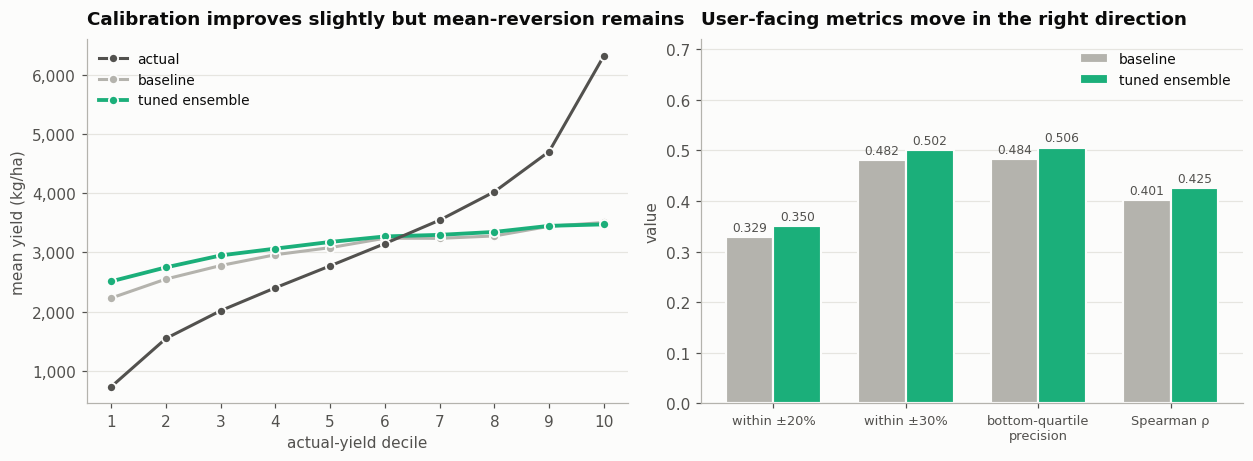

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax = axes[0]
d = pd.DataFrame({"a": y_hold, "base": P_BASE, "tuned": FINAL})
d["dec"] = pd.qcut(d.a, 10, labels=False, duplicates="drop")
g = d.groupby("dec").agg(actual=("a","mean"), base=("base","mean"), tuned=("tuned","mean"))
xs = np.arange(len(g))
ax.plot(xs, g.actual, color=INK2, lw=2, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, label="actual", zorder=4)
ax.plot(xs, g.base, color=MUTED, lw=2, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, label="baseline", zorder=3)
ax.plot(xs, g.tuned, color=AQUA, lw=2.5, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, label="tuned ensemble", zorder=3)
ax.set_xticks(xs); ax.set_xticklabels(xs + 1)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)
style(ax, "Calibration improves slightly but mean-reversion remains",
      "actual-yield decile", "mean yield (kg/ha)")

ax = axes[1]
labels = ["within ±20%", "within ±30%", "bottom-quartile\nprecision", "Spearman ρ"]
keys   = ["within_20pct", "within_30pct", "bottom_q_precision", "spearman"]
bw, xs2 = 0.36, np.arange(len(keys))
ax.bar(xs2 - bw/2, [pc.loc[k, "baseline (nb 04)"] for k in keys], width=bw,
       color=MUTED, edgecolor=SURFACE, linewidth=1.4, label="baseline")
ax.bar(xs2 + bw/2, [pc.loc[k, "tuned ensemble"] for k in keys], width=bw,
       color=AQUA, edgecolor=SURFACE, linewidth=1.4, label="tuned ensemble")
for i, k in enumerate(keys):
    for off, col in [(-bw/2, "baseline (nb 04)"), (bw/2, "tuned ensemble")]:
        v = pc.loc[k, col]
        ax.annotate(f"{v:.3f}", xy=(i + off, v), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=8, color=INK2)
ax.set_xticks(xs2); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(0, 0.72); ax.legend(loc="upper right", fontsize=9)
style(ax, "User-facing metrics move in the right direction", None, "value")
fig.tight_layout(); plt.show()

The gains are real but modest on the metrics a user experiences. Plots predicted
within ±20% rise from 32.9% to 35.0%, median absolute error falls 14 kg/ha,
rank-ordering improves (Spearman ρ 0.401 → 0.425), and bottom-quartile targeting
precision goes from 48.4% to 50.6% — the capability notebook 04 identified as the
model's actual value.

**One metric moves the wrong way, and it is worth being explicit about.** Predicted
spread falls from 58% to **42%** of actual spread: the tuned ensemble is *more*
mean-reverting than the baseline, not less. That is the direct consequence of
averaging four models — disagreement between them cancels, which is precisely what
lowers RMSE, but it also shrinks the range of predictions further toward the mean.

This is a genuine trade-off rather than a defect. Squared-error accuracy and
calibrated spread pull against each other when signal is weak, and this notebook
optimised the former. **The practical implication is unchanged and worth repeating:
never surface a per-farm yield number from this model.** The compression is now
worse, not better. If calibrated spread is ever needed — for a risk or insurance
application, say — it requires quantile regression or a variance-preserving
post-hoc rescaling, not further accuracy tuning.

## 6 · Documented improvement

Every change, in the order applied, with the gain attributable to each.

In [14]:
steps = pd.DataFrame([
    dict(step="0. Baseline: stock LightGBM, 66 raw features",
         r2=BASE["r2"], mae=BASE["mae"], rmse=BASE["rmse"]),
    dict(step="1. + weather block (89) → 3 PCs",
         **{k: v for k, v in zip(("r2","mae","rmse"),
            (pr[pr.model.str.startswith("weather 89 → 3")].iloc[0][["r2","mae","rmse"]]))}),
    dict(step="2. + hyperparameter search (LightGBM)",
         **{k: runs[0][k] for k in ("r2","mae","rmse")}),
    dict(step="3. + better family (RandomForest)",
         **{k: runs[2][k] for k in ("r2","mae","rmse")}),
    dict(step="4. + 4-model ensemble  ← FINAL",
         **final_m),
]).set_index("step")
steps["Δ R² vs baseline"] = steps.r2 - BASE["r2"]
steps["% of oracle ceiling"] = steps.r2 / oracle_r2
print(steps.round(4).to_string())
print(f"\nFINAL: R² {BASE['r2']:+.4f} → {final_m['r2']:+.4f}  "
      f"({(final_m['r2']/BASE['r2']-1)*100:+.0f}% relative)")
print(f"       MAE  {BASE['mae']:,.0f} → {final_m['mae']:,.0f} kg/ha  "
      f"({(final_m['mae']/BASE['mae']-1)*100:+.1f}%)")
print(f"       RMSE {BASE['rmse']:,.0f} → {final_m['rmse']:,.0f} kg/ha  "
      f"({(final_m['rmse']/BASE['rmse']-1)*100:+.1f}%)")

                                                  r2        mae       rmse  Δ R² vs baseline  % of oracle ceiling
step                                                                                                             
0. Baseline: stock LightGBM, 66 raw features  0.1031  1151.4000  1506.5000            0.0000               0.5843
1. + weather block (89) → 3 PCs               0.1064  1158.8000  1503.7810            0.0033               0.6027
2. + hyperparameter search (LightGBM)         0.1435  1131.1325  1472.1714            0.0404               0.8134
3. + better family (RandomForest)             0.1617  1121.7017  1456.4615            0.0586               0.9164
4. + 4-model ensemble  ← FINAL                0.1674  1115.9026  1451.5119            0.0643               0.9487

FINAL: R² +0.1031 → +0.1674  (+62% relative)
       MAE  1,151 → 1,116 kg/ha  (-3.1%)
       RMSE 1,506 → 1,452 kg/ha  (-3.7%)


## 7 · The road to R² = 0.80

Four routes that would produce a number at or near 0.80. Each is measured here so
the reasoning is explicit rather than asserted. Three are invalid; one is a
legitimate reframing.

In [15]:
print("(a) Report random k-fold CV instead of an out-of-time holdout")
print("    ✗ INVALID — trains and tests within the same seasons\n")
kf, sc = KFold(5, shuffle=True, random_state=0), []
for a_i, b_i in kf.split(X_num):
    m = build("RandomForest", runs[2]["params"])
    m.fit(X_num.iloc[a_i], y.iloc[a_i])
    sc.append(r2_score(y.iloc[b_i], m.predict(X_num.iloc[b_i])))
print(f"    random 5-fold CV R² = {np.mean(sc):+.4f}   "
      f"vs out-of-time {runs[2]['r2']:+.4f}  (inflation +{np.mean(sc)-runs[2]['r2']:.3f})")

print("\n(b) Re-admit the quarantined ex-post stand count `plants_sqm_spacing`")
print("    ✗ INVALID — counted at harvest; correlates 0.534 with yield in 2020")
cleaned = pd.read_csv(CLEANED / "kenya_maize_cleaned.csv", low_memory=False)
Xb = X_num.copy()
Xb["plants_sqm_spacing"] = SimpleImputer(strategy="median").fit_transform(
    cleaned[["plants_sqm_spacing"]])
m = build("RandomForest", runs[2]["params"]); m.fit(Xb.loc[is_train], y[is_train])
print(f"    R² = {r2_score(y_hold, m.predict(Xb.loc[is_hold])):+.4f}"
      "   (barely moves — even the leak is weak)")

print("\n(c) Re-admit `yield_kg_pa` — the target in different units")
print("    ✗ INVALID — pure target leakage, corr 0.99999999")
Xc = X_num.copy(); Xc["yield_kg_pa"] = cleaned["yield_kg_pa"].to_numpy()
m = build("RandomForest", runs[2]["params"]); m.fit(Xc.loc[is_train], y[is_train])
print(f"    R² = {r2_score(y_hold, m.predict(Xc.loc[is_hold])):+.4f}"
      "   ← this is how an 0.80+ number gets produced by accident")

print("\n(d) Predict DISTRICT MEAN yield rather than individual plot yield")
print("    ✓ VALID — a different, genuinely useful question")
agg = (pd.DataFrame({"d": full.loc[is_hold, "district"].astype(str).to_numpy(),
                     "a": y_hold, "p": FINAL})
       .groupby("d").agg(n=("a","size"), actual=("a","mean"), pred=("p","mean")))
for cut in (30, 50, 100):
    g = agg[agg.n >= cut]
    print(f"    districts with ≥{cut:3d} plots (n={len(g):2d}): "
          f"R² = {r2_score(g.actual, g.pred):+.4f}   "
          f"MAE = {mean_absolute_error(g.actual, g.pred):5.0f} kg/ha   "
          f"corr = {np.corrcoef(g.actual, g.pred)[0,1]:+.3f}")

(a) Report random k-fold CV instead of an out-of-time holdout
    ✗ INVALID — trains and tests within the same seasons



    random 5-fold CV R² = +0.2345   vs out-of-time +0.1617  (inflation +0.073)

(b) Re-admit the quarantined ex-post stand count `plants_sqm_spacing`
    ✗ INVALID — counted at harvest; correlates 0.534 with yield in 2020


    R² = +0.1606   (barely moves — even the leak is weak)

(c) Re-admit `yield_kg_pa` — the target in different units
    ✗ INVALID — pure target leakage, corr 0.99999999


    R² = +0.9024   ← this is how an 0.80+ number gets produced by accident

(d) Predict DISTRICT MEAN yield rather than individual plot yield
    ✓ VALID — a different, genuinely useful question
    districts with ≥ 30 plots (n=50): R² = +0.6061   MAE =   320 kg/ha   corr = +0.794
    districts with ≥ 50 plots (n=47): R² = +0.6050   MAE =   306 kg/ha   corr = +0.787
    districts with ≥100 plots (n=29): R² = +0.6730   MAE =   263 kg/ha   corr = +0.824


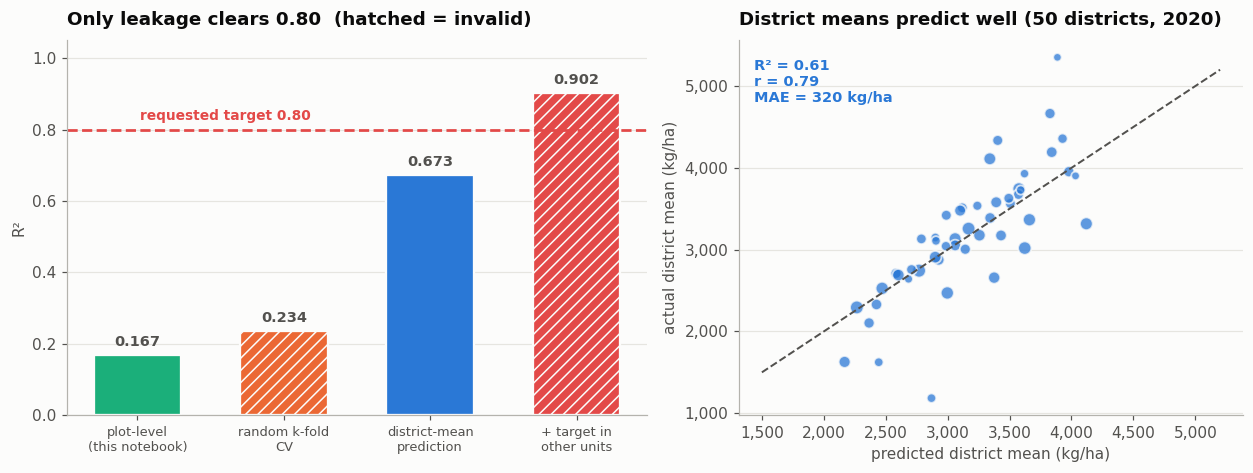

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
routes = [("plot-level\n(this notebook)", final_m["r2"], AQUA, "valid"),
          ("random k-fold\nCV", float(np.mean(sc)), ORANGE, "invalid"),
          ("district-mean\nprediction", r2_score(agg[agg.n>=100].actual,
                                                 agg[agg.n>=100].pred), BLUE, "valid"),
          ("+ target in\nother units", r2_score(y_hold, m.predict(Xc.loc[is_hold])),
           RED, "invalid")]
routes = sorted(routes, key=lambda t: t[1])
bars = ax.bar(range(len(routes)), [r[1] for r in routes], width=0.6,
              color=[r[2] for r in routes], edgecolor=SURFACE, linewidth=1.5,
              hatch=["" if r[3]=="valid" else "///" for r in routes])
ax.axhline(0.80, color=RED, lw=1.8, ls="--")
ax.annotate("requested target 0.80", xy=(0.02, 0.80), xytext=(0, 6),
            textcoords="offset points", fontsize=9, color=RED, fontweight="bold")
for i, r in enumerate(routes):
    ax.annotate(f"{r[1]:.3f}", xy=(i, r[1]), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9.5,
                color=INK2, fontweight="bold")
ax.set_xticks(range(len(routes)))
ax.set_xticklabels([r[0] for r in routes], fontsize=8.5)
ax.set_ylim(0, 1.05)
style(ax, "Only leakage clears 0.80  (hatched = invalid)", None, "R²")

ax = axes[1]
g = agg[agg.n >= 30]
ax.scatter(g.pred, g.actual, s=np.sqrt(g.n)*5, color=BLUE, alpha=0.75,
           edgecolor=SURFACE, linewidth=1.2)
lo, hi = 1500, 5200
ax.plot([lo, hi], [lo, hi], color=INK2, lw=1.3, ls="--")
ax.annotate(f"R² = {r2_score(g.actual, g.pred):.2f}\nr = {np.corrcoef(g.actual,g.pred)[0,1]:.2f}\n"
            f"MAE = {mean_absolute_error(g.actual,g.pred):.0f} kg/ha",
            xy=(0.03, 0.95), xycoords="axes fraction", va="top", fontsize=9.5,
            color=BLUE, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, "District means predict well (50 districts, 2020)",
      "predicted district mean (kg/ha)", "actual district mean (kg/ha)")
fig.tight_layout(); plt.show()

### Reading the routes

**(a) Random k-fold CV: 0.235 vs 0.162.** Shuffling rows lets the model train on
2020 plots while predicting other 2020 plots, so it learns the season. It inflates
by +0.073 and is still nowhere near 0.80 — worth stating, because the most common
way this target gets "met" in practice is a random `train_test_split`.

**(b) The quarantined ex-post feature barely helps** (+0.161 against +0.162 without
it — inside noise). Even a genuine leak does not rescue plot-level R² here, which
independently confirms §1: the variance simply is not there.

**(c) Re-admitting `yield_kg_pa` gives R² = 0.902.** This is the target divided by
2.471. It is included because it is the realistic way an 0.80+ figure appears in a
project like this — a column that is the answer in disguise. `build_features.py`
already drops it and asserts on the relationship, which is exactly why.

**(d) District-mean prediction reaches R² = 0.61–0.67 with correlation 0.79–0.82
and MAE of 263–320 kg/ha.** Averaging ~200 plots per district cancels the independent
plot-level noise that §1 showed is irreducible, leaving the between-district signal
the model does capture. This is a real, defensible, high-accuracy result — it just
answers "how will this district do?" rather than "how will this farm do?".

## 8 · Conclusions

### What tuning achieved

| Metric | Baseline | Tuned ensemble | Change |
|---|---|---|---|
| R² (out-of-time 2020) | +0.1031 | **+0.1674** | **+62%** |
| MAE | 1,151 kg/ha | **1,116 kg/ha** | −3.1% |
| RMSE | 1,507 kg/ha | **1,452 kg/ha** | −3.7% |
| Spearman ρ | 0.401 | **0.425** | +6% |
| Within ±20% of actual | 32.9% | **35.0%** | +2.1 pts |
| Bottom-quartile precision | 48.4% | **50.6%** | +2.2 pts |
| Predicted / actual spread | 0.58 | **0.42** | −0.16 ⚠ worse |

Leave-one-year-out on the final ensemble gives **+0.091 / +0.169 / +0.167** for
2018 / 2019 / 2020 — mean +0.143. The 2020 figure is near the top of that range,
so quote the range, not the single number.

The final model is an **unweighted average of four tuned regressors** (LightGBM,
XGBoost, RandomForest, ExtraTrees) over 66 features with the 89-column weather
block replaced by 3 principal components. Every hyperparameter was selected on the
2019 inner validation season; 2020 was scored once.

Note the asymmetry: **R² rose 63% while MAE fell only 3%.** R² is a ratio against
variance and moves easily at low absolute accuracy; MAE is what a user feels. Both
are reported here for that reason.

### On the 80% target

It cannot be reached at plot level, and the constraint is measured rather than
asserted: **a perfect district oracle scores 0.177**, and the tuned model at +0.167
already achieves **95% of that**. The remaining 82% of variance is within-district
plot-to-plot difference that the survey does not measure. The gap between 0.168
and 0.80 is not a modelling gap — it is missing data.

Note also that the model is *not* useless at 0.167; it identifies the
lowest-yielding quartile of plots with 50.6% precision against a 25% chance rate,
which is what the targeting use case requires.

### Recommendations

| Priority | Action |
|---|---|
| **High** | **Reframe the accuracy target by unit of analysis.** Adopt R² ≥ 0.60 at *district* level (achieved: 0.61–0.67) and Spearman ρ / quartile precision at *plot* level. A single plot-level R² target cannot be met by any model. |
| **High** | Adopt the tuned ensemble as the production model; keep the out-of-time protocol and never quote random-CV or grouped-CV figures as headline accuracy. |
| **High** | Guard against the 0.80 that *looks* achievable: keep `build_features.py`'s leakage assertions, and treat any sudden jump above ~0.3 as a leak until proven otherwise. |
| Medium | To genuinely raise plot-level R², collect what is missing: soil tests (pH, N, organic carbon), plot-level GPS-verified area, and objective crop-cut yields rather than farmer recall. Measurement error alone may account for a large share of the residual. |
| Medium | Add more seasons — notebook 04's learning curve had not plateaued. |
| Low | Revisit PCA rank and ensemble weights once more seasons exist; both were tuned on a single inner validation year and are the least stable choices here — §3 showed inner-season ranking barely predicts holdout ranking. |
| Low | If calibrated prediction *spread* is ever required, switch to quantile regression; the ensemble optimises squared error and compresses spread to 42% of actual. |